# Image Filtering

The code bellow implements a python function that loads an image that is taken as input and applies a selected filter (box, gaussian, median, unsharp or sobel) with default parameters that can be changed if needed. The following results shows the effect of each filter and briefly describe how the image is modified in each case.

The image shown can be easilly changed by changing the path in the `PATH` variable. However, some of the observations are specifically focused on the cameraman image.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

PATH = "../images/task3/cameraman.tif"

def apply_filter(image_filename, filter_type,
                 ksize=5, sigma=1.0, amount=1.0, dx=1, dy=1):

    img = cv2.imread(image_filename)
    if img is None:
        print("Error: Image not found.")
        return
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if filter_type.lower() == 'box':
        filtered = cv2.blur(img, (ksize, ksize))

    elif filter_type.lower() == 'gaussian':
        filtered = cv2.GaussianBlur(img, (ksize, ksize), sigma)

    elif filter_type.lower() == 'median':
        filtered = cv2.medianBlur(img, ksize)

    elif filter_type.lower() == 'unsharp':
        blurred = cv2.GaussianBlur(img, (ksize, ksize), sigma)
        filtered = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)

    elif filter_type.lower() == 'sobel':
        sobel = cv2.Sobel(img, cv2.CV_64F, dx, dy, ksize=3)
        filtered = np.uint8(np.abs(sobel))

    else:
        print("Filter type not recognized.")
        return

    # Display results
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title('Original')
    plt.subplot(1,2,2)
    plt.imshow(filtered)
    plt.title(f'{filter_type} Filter')
    plt.show()

## Box Filter (Smoothing)

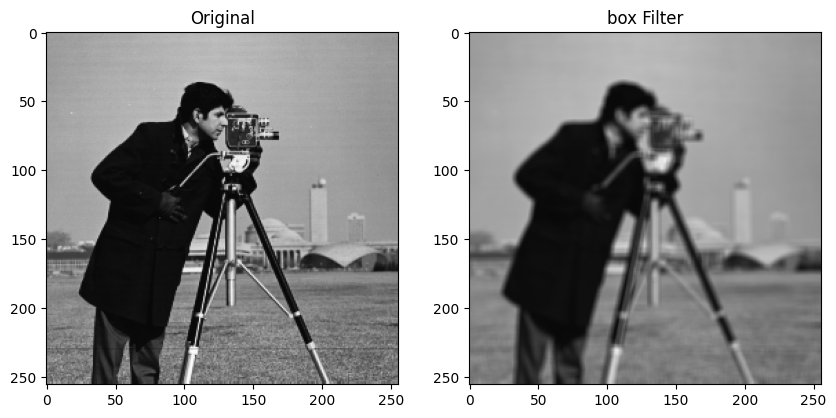

In [2]:
apply_filter(PATH, 'box')

The box filter smooths the image by replacing each pixel with the average of its neighborhood. This reduces high-frequency components such as noise and fine details. As a result, the image appears blurred and edges become softer because intensity variations are averaged out. In the image above (cameraman image) the effect of the box filter is noticeable as both the background and the cameraman appear blurred, with less distinction between the cameraman and the background.

## Gaussian Filter (Smoothing)

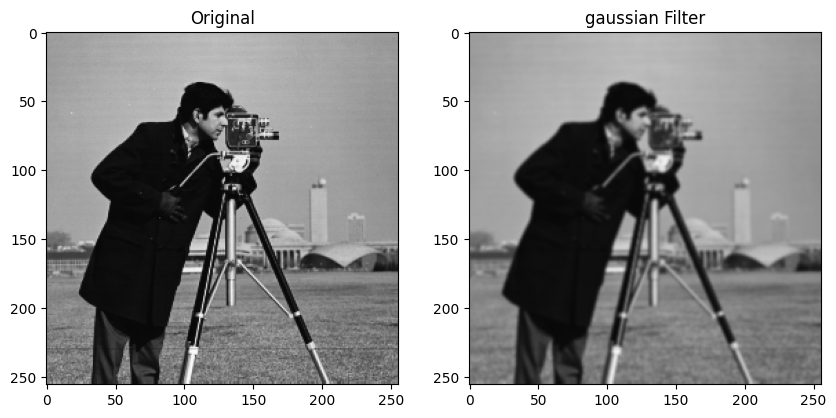

In [3]:
apply_filter(PATH, 'gaussian')

The Gaussian filter also smooths the image, however it uses weighted averaging where central pixels have a higher contribution. This reduces the noise and high-frequency details while preserving structure better than the box filter. The blur appears more natural and less harsh. In the image above (cameraman image) the filter effect is visible as both the background and the cameraman are smoothly blurred, giving the image a softer and more uniform appearance when compared to the original version.

## Median Filter (Impulse Noise Robustness)

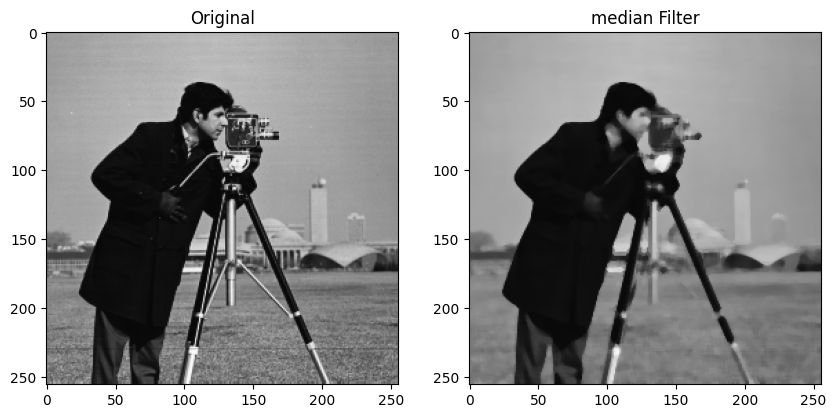

In [4]:
apply_filter(PATH, 'median')

The median filter is a non-linear digital filtering that replaces each pixel with the meadian value of its neighborhood. This technique removes impulse (salt-and-pepper) noise, characterized by black and white pixels scattered across an image, while preserving edges better than averaging filters. Since it is a nonlinear filter, it does not blur edges strongly. The filter characterisctics are clearly seen in the filtered image, as noise is reduced while the edges of the main objects (the camera and the man in the cameraman image) remain sharp and well defined.

## Unsharp Masking (Sharpning)

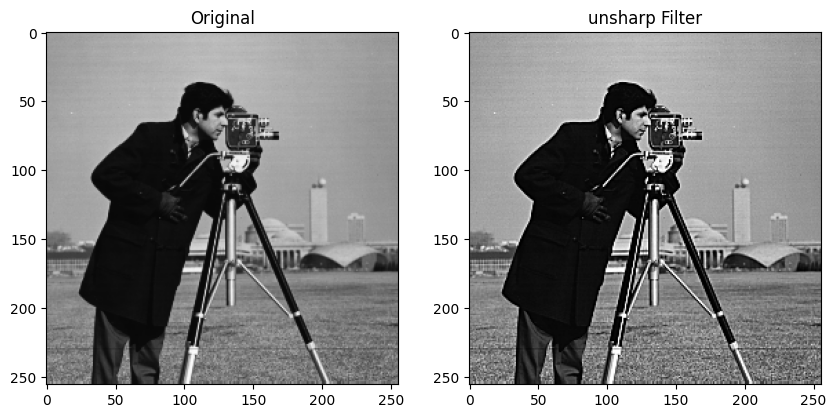

In [5]:
apply_filter(PATH, 'unsharp')

The unsharp masking filter is a technique that emhances the contrast of edges making images appear clearer and more detailed. This method subtracts a blurred version of the image from the original. This increases high-frequency components, making edges and fine details more pronounced. In the cameraman image, the effect of the unsharp masking filter is noticeable as the contourns of the man and the camera become more defined while the overall image appears sharper as well. However, excessive sharpening may amplify the noise of the image (as it is seen in the ruido1 image).

## Sobel Filter (Edge Detection)

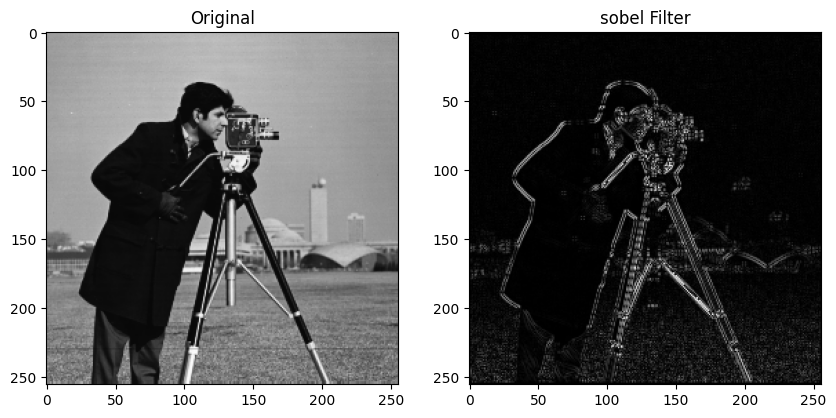

In [6]:
apply_filter(PATH, 'sobel')

The sobel filter computes the image gradient, highlighting areas with strong intensity changes. Uniform regions become darker, while edges appear bright. This occurs because the filter approximates the first derivative of the image, which responds strongly to rapid intensity variations. In the cameraman image, this is clearly visible, since the background is almost completely dark as it is nearly uniform, while the man and the camera are brightly outlined, as those are the regions with the strongest intensity changes.

## Extra

In this section, the code used in the `apply_filter` function was adapted to apply every filter to each image available for this task and store the results in separate folders organized by filter type. For each case, the original and the filtered images are saved side by side, allowing the comparison between the original image and the filtered one.

In [7]:
import os

def save_all_filter_outputs(input_folder="../images/task3/",
                            output_root="filterOutputs",
                            ksize=5, sigma=1.0, amount=1.0, dx=1, dy=1):

    filters = ['box', 'gaussian', 'median', 'unsharp', 'sobel']

    os.makedirs(output_root, exist_ok=True)

    image_files = [f for f in os.listdir(input_folder)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))]

    for filter_type in filters:

        filter_folder = os.path.join(output_root, filter_type)
        os.makedirs(filter_folder, exist_ok=True)

        for filename in image_files:

            img_path = os.path.join(input_folder, filename)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if filter_type == 'box':
                filtered = cv2.blur(img, (ksize, ksize))

            elif filter_type == 'gaussian':
                filtered = cv2.GaussianBlur(img, (ksize, ksize), sigma)

            elif filter_type == 'median':
                filtered = cv2.medianBlur(img, ksize)

            elif filter_type == 'unsharp':
                blurred = cv2.GaussianBlur(img, (ksize, ksize), sigma)
                filtered = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)

            elif filter_type == 'sobel':
                sobel = cv2.Sobel(img, cv2.CV_64F, dx, dy, ksize=3)
                sobel = cv2.normalize(sobel, None, 0, 255, cv2.NORM_MINMAX)
                filtered = np.uint8(sobel)

            filtered_rgb = cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(10,5))

            plt.subplot(1,2,1)
            plt.imshow(img_rgb)
            plt.title('Original')
            plt.axis('off')

            plt.subplot(1,2,2)
            plt.imshow(filtered_rgb)
            plt.title(f'{filter_type} Filter')
            plt.axis('off')

            output_path = os.path.join(
                filter_folder,
                filename.split('.')[0] + '.png'
            )

            plt.savefig(output_path, bbox_inches='tight')
            plt.close()


save_all_filter_outputs()